In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/creditcard.csv")

In [3]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
fraud_rate = df["Class"].mean() * 100
fraud_rate

np.float64(0.1727485630620034)

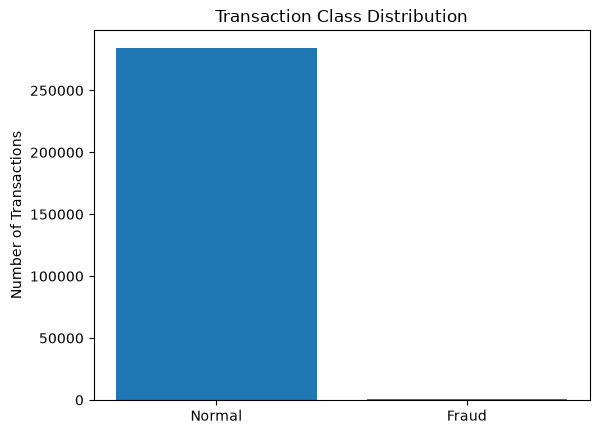

In [6]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

plt.bar(["Normal", "Fraud"], class_counts.values)
plt.title("Transaction Class Distribution")
plt.ylabel("Number of Transactions")
plt.show()

In [7]:
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

normal["Amount"].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [8]:
fraud["Amount"].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

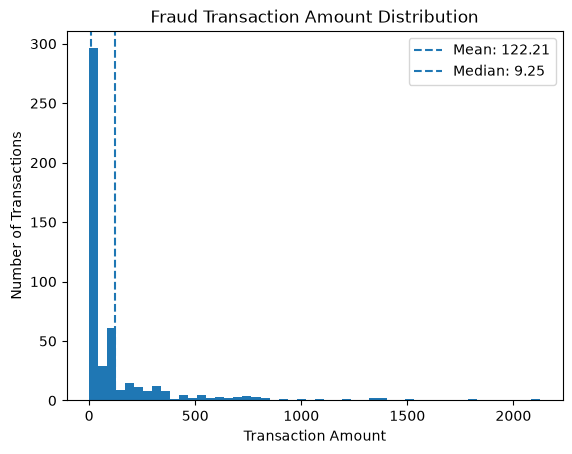

In [9]:
plt.hist(fraud["Amount"], bins=50)

plt.axvline(
    fraud["Amount"].mean(),
    linestyle="--",
    label=f"Mean: {fraud['Amount'].mean():.2f}"
)

plt.axvline(
    fraud["Amount"].median(),
    linestyle="--",
    label=f"Median: {fraud['Amount'].median():.2f}"
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Fraud Transaction Amount Distribution")
plt.legend()

plt.show()

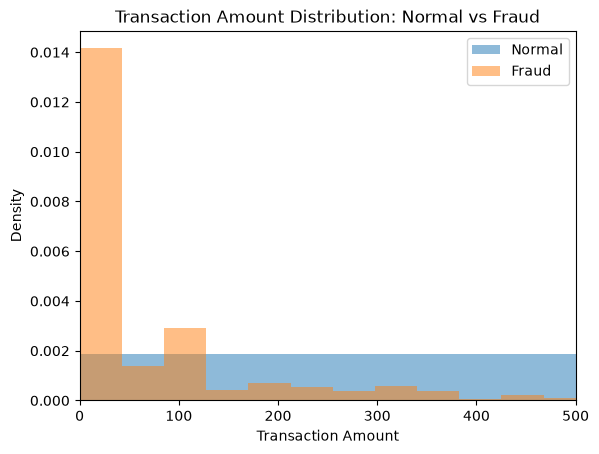

In [10]:
plt.hist(
    normal["Amount"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Normal"
)

plt.hist(
    fraud["Amount"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Fraud"
)

plt.xlim(0, 500)

plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.title("Transaction Amount Distribution: Normal vs Fraud")
plt.legend()

plt.show()

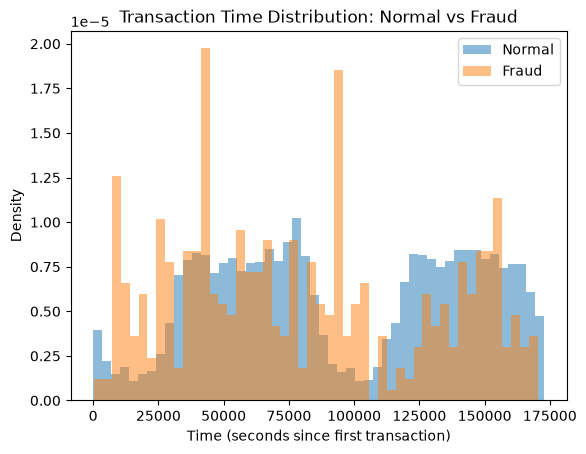

In [11]:
plt.hist(
    normal["Time"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Normal"
)

plt.hist(
    fraud["Time"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Fraud"
)

plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Density")
plt.title("Transaction Time Distribution: Normal vs Fraud")
plt.legend()

plt.show()

In [12]:
features = [f"V{i}" for i in range(1, 29)]

comparison = pd.DataFrame({
    "Normal Mean": normal[features].mean(),
    "Fraud Mean": fraud[features].mean()
})

comparison["Difference"] = (
    comparison["Fraud Mean"] - comparison["Normal Mean"]
).abs()

comparison.sort_values("Difference", ascending=False).head(10)

,Normal Mean,Fraud Mean,Difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749


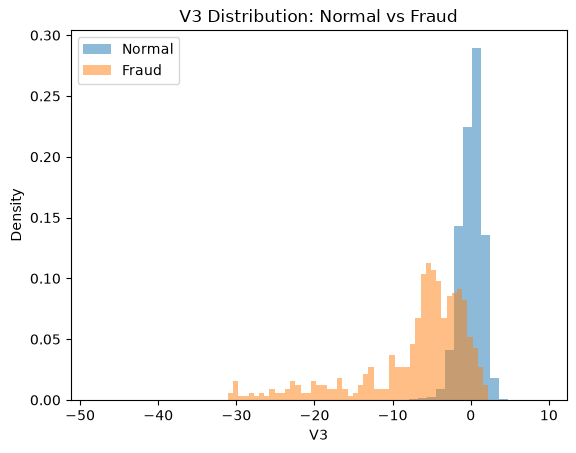

In [13]:
plt.hist(
    normal["V3"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Normal"
)

plt.hist(
    fraud["V3"],
    bins=50,
    alpha=0.5,
    density=True,
    label="Fraud"
)

plt.xlabel("V3")
plt.ylabel("Density")
plt.title("V3 Distribution: Normal vs Fraud")
plt.legend()

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [15]:
print("Training:", X_train.shape)
print("Test:", X_test.shape)

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTest classes:")
print(y_test.value_counts())

Training: (227845, 30)
Test: (56962, 30)

Training classes:
Class
0    227451
1       394
Name: count, dtype: int64

Test classes:
Class
0    56864
1       98
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [17]:
X_train_scaled[["Time", "Amount"]].describe()

,Time,Amount
count,2.278450e+05,2.278450e+05
mean,-1.409578e-16,3.742243e-17
std,1.000002e+00,1.000002e+00
min,-1.998073e+00,-3.516894e-01
25%,-8.561495e-01,-3.291944e-01
50%,-2.122647e-01,-2.639429e-01
75%,9.366285e-01,-4.262209e-02
max,1.640549e+00,1.021170e+02


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [19]:
y_pred = model.predict(X_test_scaled)

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[55478,  1386],
       [    8,    90]])

In [21]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [22]:
from sklearn.metrics import precision_score, recall_score

for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.5 | Precision: 0.061 | Recall: 0.918
Threshold: 0.6 | Precision: 0.087 | Recall: 0.908
Threshold: 0.7 | Precision: 0.121 | Recall: 0.908
Threshold: 0.8 | Precision: 0.161 | Recall: 0.898
Threshold: 0.9 | Precision: 0.245 | Recall: 0.888


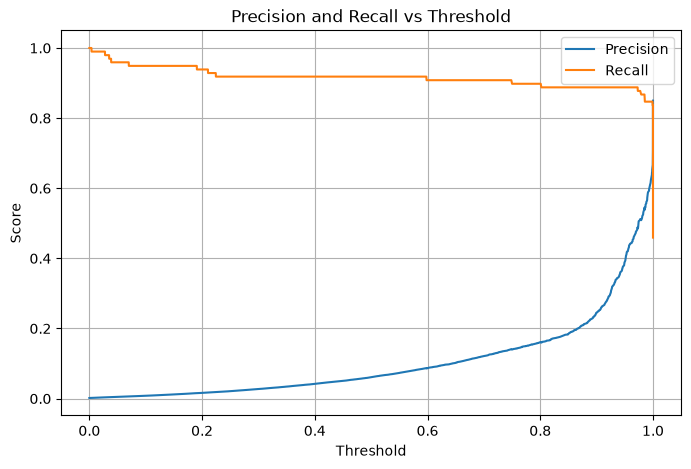

In [23]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [24]:
results = []

for threshold in [0.95, 0.96, 0.97, 0.98, 0.99]:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)

    results.append((threshold, precision, recall))

for threshold, precision, recall in results:
    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.95 | Precision: 0.392 | Recall: 0.888
Threshold: 0.96 | Precision: 0.444 | Recall: 0.888
Threshold: 0.97 | Precision: 0.478 | Recall: 0.888
Threshold: 0.98 | Precision: 0.515 | Recall: 0.867
Threshold: 0.99 | Precision: 0.576 | Recall: 0.847


In [25]:
from sklearn.metrics import confusion_matrix

threshold = 0.98
y_pred_final = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_final)
cm

array([[56784,    80],
       [   13,    85]])

In [26]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

ROC-AUC: 0.9722
PR-AUC:  0.7159


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [28]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print(f"Random Forest ROC-AUC: {rf_roc_auc:.4f}")
print(f"Random Forest PR-AUC:  {rf_pr_auc:.4f}")

Random Forest ROC-AUC: 0.9613
Random Forest PR-AUC:  0.8669


In [29]:
from sklearn.metrics import precision_recall_curve

rf_precision, rf_recall, rf_thresholds = precision_recall_curve(
    y_test, rf_prob
)

valid = rf_recall[:-1] >= 0.85

best_index = (
    rf_precision[:-1][valid]
).argmax()

valid_indices = valid.nonzero()[0]
best_index = valid_indices[best_index]

best_threshold = rf_thresholds[best_index]
best_precision = rf_precision[best_index]
best_recall = rf_recall[best_index]

print(f"Best threshold: {best_threshold:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")

Best threshold: 0.3100
Precision: 0.8400
Recall: 0.8571


In [30]:
rf_pred_final = (rf_prob >= best_threshold).astype(int)

rf_cm = confusion_matrix(y_test, rf_pred_final)
rf_cm

array([[56848,    16],
       [   14,    84]])

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

V14    0.181220
V4     0.117300
V10    0.108266
V12    0.098100
V17    0.087768
V3     0.062882
V16    0.054004
V11    0.051953
V2     0.030927
V7     0.021247
dtype: float64

In [32]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=200,
    random_state=42
)

hgb_model.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.08
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [33]:
hgb_prob = hgb_model.predict_proba(X_test)[:, 1]

hgb_roc_auc = roc_auc_score(y_test, hgb_prob)
hgb_pr_auc = average_precision_score(y_test, hgb_prob)

print(f"HistGradientBoosting ROC-AUC: {hgb_roc_auc:.4f}")
print(f"HistGradientBoosting PR-AUC:  {hgb_pr_auc:.4f}")

HistGradientBoosting ROC-AUC: 0.7815
HistGradientBoosting PR-AUC:  0.5078


In [34]:
hgb_precision, hgb_recall, hgb_thresholds = precision_recall_curve(
    y_test, hgb_prob
)

valid = hgb_recall[:-1] >= 0.85
valid_indices = valid.nonzero()[0]

best_local_index = hgb_precision[:-1][valid].argmax()
best_index = valid_indices[best_local_index]

hgb_best_threshold = hgb_thresholds[best_index]
hgb_best_precision = hgb_precision[best_index]
hgb_best_recall = hgb_recall[best_index]

print(f"Best threshold: {hgb_best_threshold:.4f}")
print(f"Precision: {hgb_best_precision:.4f}")
print(f"Recall: {hgb_best_recall:.4f}")

Best threshold: 0.0000
Precision: 0.0017
Recall: 1.0000


In [35]:
X = df.drop("Class", axis=1)
y = df["Class"]

# Önce %70 train, %30 geçici set
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Geçici %30'u ikiye böl: %15 validation + %15 test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.value_counts().to_dict())
print("Validation:", X_val.shape, y_val.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

Train: (199364, 30) {0: 199020, 1: 344}
Validation: (42721, 30) {0: 42647, 1: 74}
Test: (42722, 30) {0: 42648, 1: 74}


In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Sadece TRAIN üzerinde öğren
scaler.fit(X_train[["Time", "Amount"]])

# Öğrendiği dönüşümü üç sete uygula
X_train_scaled[["Time", "Amount"]] = scaler.transform(
    X_train[["Time", "Amount"]]
)

X_val_scaled[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

X_test_scaled[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [39]:
X_train_scaled[["Time", "Amount"]].describe()

,Time,Amount
count,1.993640e+05,1.993640e+05
mean,-1.062086e-16,1.553925e-17
std,1.000003e+00,1.000003e+00
min,-1.998286e+00,-3.492566e-01
25%,-8.558564e-01,-3.268514e-01
50%,-2.116814e-01,-2.623226e-01
75%,9.363437e-01,-4.301173e-02
max,1.640221e+00,1.011706e+02


In [40]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [41]:
log_val_prob = log_model.predict_proba(X_val_scaled)[:, 1]

log_val_roc = roc_auc_score(y_val, log_val_prob)
log_val_pr = average_precision_score(y_val, log_val_prob)

print(f"Validation ROC-AUC: {log_val_roc:.4f}")
print(f"Validation PR-AUC:  {log_val_pr:.4f}")

Validation ROC-AUC: 0.9684
Validation PR-AUC:  0.6275


In [42]:
from sklearn.metrics import precision_recall_curve

log_precision, log_recall, log_thresholds = precision_recall_curve(
    y_val, log_val_prob
)

valid = log_recall[:-1] >= 0.85
valid_indices = valid.nonzero()[0]

best_local_index = log_precision[:-1][valid].argmax()
best_index = valid_indices[best_local_index]

log_best_threshold = log_thresholds[best_index]
log_best_precision = log_precision[best_index]
log_best_recall = log_recall[best_index]

print(f"Best threshold: {log_best_threshold:.4f}")
print(f"Precision: {log_best_precision:.4f}")
print(f"Recall: {log_best_recall:.4f}")

Best threshold: 0.8505
Precision: 0.2100
Recall: 0.8514


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_val_prob = rf_model.predict_proba(X_val)[:, 1]

rf_val_roc = roc_auc_score(y_val, rf_val_prob)
rf_val_pr = average_precision_score(y_val, rf_val_prob)

print(f"Random Forest Validation ROC-AUC: {rf_val_roc:.4f}")
print(f"Random Forest Validation PR-AUC:  {rf_val_pr:.4f}")

Random Forest Validation ROC-AUC: 0.9478
Random Forest Validation PR-AUC:  0.8103


In [44]:
rf_precision, rf_recall, rf_thresholds = precision_recall_curve(
    y_val, rf_val_prob
)

valid = rf_recall[:-1] >= 0.85
valid_indices = valid.nonzero()[0]

best_local_index = rf_precision[:-1][valid].argmax()
best_index = valid_indices[best_local_index]

rf_best_threshold = rf_thresholds[best_index]
rf_best_precision = rf_precision[best_index]
rf_best_recall = rf_recall[best_index]

print(f"Best threshold: {rf_best_threshold:.4f}")
print(f"Precision: {rf_best_precision:.4f}")
print(f"Recall: {rf_best_recall:.4f}")

Best threshold: 0.0150
Precision: 0.1123
Recall: 0.8514


In [45]:
log_test_prob = log_model.predict_proba(X_test_scaled)[:, 1]

log_test_pred = (
    log_test_prob >= log_best_threshold
).astype(int)

cm_final = confusion_matrix(y_test, log_test_pred)

final_precision = precision_score(y_test, log_test_pred)
final_recall = recall_score(y_test, log_test_pred)
final_roc = roc_auc_score(y_test, log_test_prob)
final_pr = average_precision_score(y_test, log_test_prob)

print("Confusion Matrix:")
print(cm_final)

print(f"\nPrecision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"ROC-AUC:   {final_roc:.4f}")
print(f"PR-AUC:    {final_pr:.4f}")

Confusion Matrix:
[[42414   234]
 [   11    63]]

Precision: 0.2121
Recall:    0.8514
ROC-AUC:   0.9675
PR-AUC:    0.7904
